# AdaJEPA, reproduced: test-time adaptation of a latent world model inside MPC

**Paper**: *AdaJEPA: An Adaptive Latent World Model* — Wang, Bounou, LeCun, Ren (NYU, arXiv [2606.32026](https://arxiv.org/abs/2606.32026)).

**Core claim.** Latent world models (JEPA encoder $\mathcal{E}$ + predictor $f$) are normally **frozen** during MPC planning. When their predictions are wrong — especially under test-time distribution shift — the planner optimizes the wrong objective and fails. AdaJEPA instead closes the loop: after each executed action chunk, the observed transition $(o_t, a_t, o_{t+1})$ becomes a **self-supervised adaptation target**,

$$\mathcal{L}_{\rm ada}(\mathcal{B}) = \frac{1}{|\mathcal{B}|} \sum_{(o_i, a_i, o_{i+1}) \in \mathcal{B}} \ell\big(f(\mathcal{E}(o_i), \mathcal{E}_a(a_i)),\ \operatorname{sg}(\mathcal{E}(o_{i+1}))\big),$$

and **one gradient step** on a small parameter subset (last predictor block + encoder projection head) recalibrates the model before the next replan. Plan → execute → adapt → replan.

**This notebook** walks through each assumption of the paper on a miniaturized but faithful reproduction (`research/adajepa/`, fully isolated from the rest of the repo): a from-scratch numpy PointMaze with the paper's dynamics/visual/layout shift axes, a 1.2M-parameter JEPA world model, CEM/GD MPC planners, and the AdaJEPA adapter with paper defaults (1 step, recent-5 buffer, `predlast+enclast`).

**Claims under test** (paper section in parentheses):

1. TTA improves planning success under **dynamics shifts** (§4.2, Table 1) and **visual shifts** (§4.2, Fig. 2).
2. TTA helps on **held-out maze layouts** (§4.2, Table 1 layout shift).
3. TTA is **safe in-distribution** — no harm when the frozen model is already good (§4.2).
4. Adapted success **keeps rising with replanning steps** while the frozen model saturates (§4.2, Fig. 2).
5. Adaptation **reduces the per-replan latent prediction loss** — the mechanism (§C, Figs. 10–13).
6. Gains are **robust to the adaptation target**; last-layer updates suffice (§4.3, Fig. 7).
7. TTA **compensates for scarce training data** (§4.4, Fig. 5).
8. The adaptation step adds only **negligible latency** (§4.2, Table 2).

> Results JSONs are produced by the CLI (`python -m adajepa.cli ...`, see `README.md`); the notebook renders them and re-runs small live demos. Reproduction caveats are collected in the final section.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from adajepa.device import torch_device
from adajepa.env import EnvConfig, PointMazeEnv, make_shift_config, SHIFT_NAMES
from adajepa.model import load_checkpoint
from adajepa.planner import PlannerConfig
from adajepa.eval import EvalConfig, run_episode, success_by_step
from adajepa.tta import AdaptConfig

RUNS = ROOT / "runs"
device = torch_device()
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("device:", device)

device: mps


## 1. The environment and the paper's shift axes

The paper evaluates on PushT/PushObj (pymunk) and PointMaze (MuJoCo). To keep the reproduction dependency-free and fast, we use a from-scratch **numpy PointMaze**: a point mass in a randomly generated connected maze, driven by 2D force actions, rendered to 64×64 RGB. The observation is a channel-stack of the last 2 frames (the paper uses a 3-frame history for the same reason: a single image can't reveal velocity).

The paper's train→test shifts map onto env knobs:

| Paper shift | Here |
|---|---|
| Dynamics: low mass ×0.2 | `mass = 0.2` (same force ⇒ 5× acceleration) |
| Dynamics: high damping ×20 | `damping × 8` (×20 makes goals physically unreachable under this integrator — see caveats) |
| Visual: blur / salt-and-pepper / dark | per-frame corruptions at render time |
| Visual: agent recolor (blue→red) | `red_agent` |
| Layout: held-out mazes | train on layout seeds 0–7, test on 100–102 |

Shape shifts (PushObj) need object manipulation and are out of scope for this navigation env.

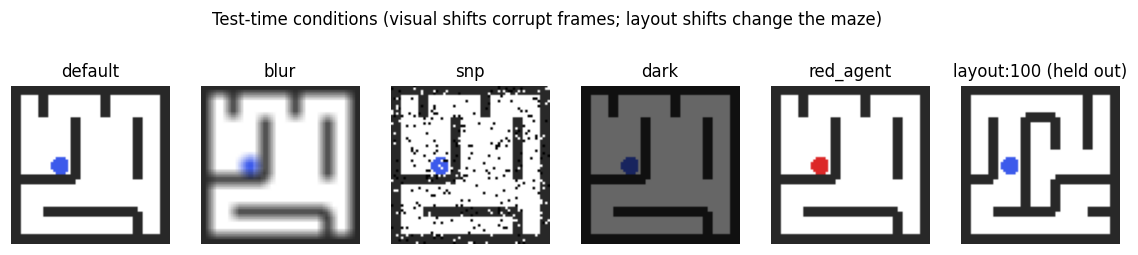

In [2]:
# Render the shift suite: same maze/pose, different test-time conditions.
shifts_to_show = ["default", "blur", "snp", "dark", "red_agent"]
fig, axes = plt.subplots(1, len(shifts_to_show) + 1, figsize=(13, 2.4))
for ax, shift in zip(axes, shifts_to_show):
    env = PointMazeEnv(make_shift_config(EnvConfig(), shift))
    env.reset(pos=np.array([2.5, 1.5]))
    ax.imshow(env.render_frame())
    ax.set_title(shift)
    ax.axis("off")
env = PointMazeEnv(EnvConfig(layout_seed=100))
env.reset(pos=np.array([2.5, 1.5]))
axes[-1].imshow(env.render_frame())
axes[-1].set_title("layout:100 (held out)")
axes[-1].axis("off")
fig.suptitle("Test-time conditions (visual shifts corrupt frames; layout shifts change the maze)", y=1.08)
plt.show()

## 2. The JEPA world model (paper §3.1)

Assumption 0 of the whole paper: you can train, from **reward-free offline trajectories** alone, a latent space where (a) the predictor tracks true dynamics and (b) latent distance to a goal embedding is a usable planning cost.

- **Encoder** $\mathcal{E}$: 4-conv CNN → 128-d latent with a Linear–GELU–Linear–LayerNorm projection head (the paper's ResNet-global-features analogue; the head is the `enclast` adaptation target).
- **Predictor** $f$: 3 residual MLP blocks + LayerNorm + head, predicting a latent **delta** (their transformer analogue; first/last blocks are the `predfirst`/`predlast` targets).
- **Objective** (eq. 2): multi-step latent prediction ($K{=}4$) with a stop-gradient target, smooth-L1 on LayerNorm'd embeddings, plus VICReg variance/covariance insurance **and a temporal-contrast ("motion") hinge** pushing embeddings $K$ steps apart to differ. The paper notes either stop-grad or a regularizer is admissible; at this small scale we found two shortcut modes that required both extra terms (see the findings section — each was invisible in the training loss and only detectable with the plannability probes below).

Data: 1,500 trajectories × 32 steps from an Ornstein–Uhlenbeck exploration policy. Training: 12 epochs, ~3 min on Apple MPS.

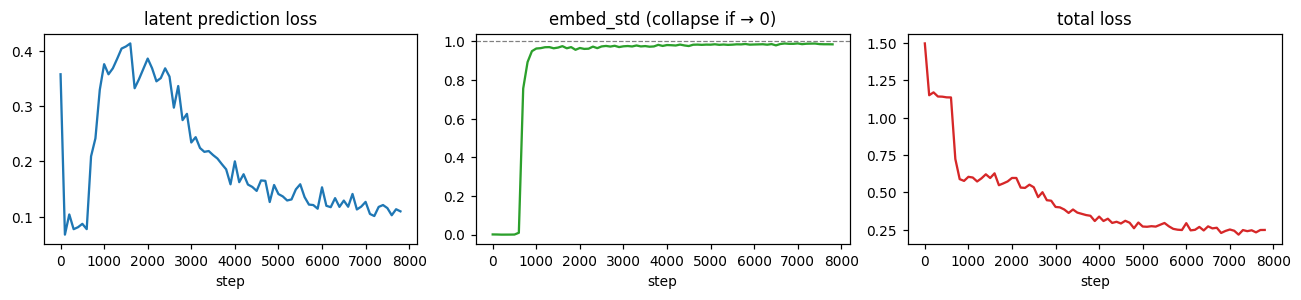

params: 1.23M


In [3]:
model = load_checkpoint(RUNS / "base_l0.pt", device)
history = json.loads((RUNS / "base_l0.train.json").read_text())["history"]

fig, axes = plt.subplots(1, 3, figsize=(12, 2.8))
steps = [h["step"] for h in history]
axes[0].plot(steps, [h["pred_loss"] for h in history])
axes[0].set_title("latent prediction loss")
axes[1].plot(steps, [h["embed_std"] for h in history], color="tab:green")
axes[1].axhline(1.0, ls="--", c="gray", lw=0.8)
axes[1].set_title("embed_std (collapse if → 0)")
axes[2].plot(steps, [h["loss"] for h in history], color="tab:red")
axes[2].set_title("total loss")
for ax in axes:
    ax.set_xlabel("step")
plt.tight_layout()
plt.show()
print("params:", f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M")

### 2a. Is the latent space plannable?

Two sanity probes behind the paper's MPC assumption (eq. 3: minimize $\|\hat z - z_g\|_2^2$ over action sequences):

1. **Latent–position correspondence**: squared latent distance between two states should grow with their physical distance.
2. **Rollout fidelity**: the predictor's imagined latent trajectory should track the encoder's latents of the real trajectory better than the trivial "stay at $z_0$" baseline — otherwise MPC has no signal about action consequences.

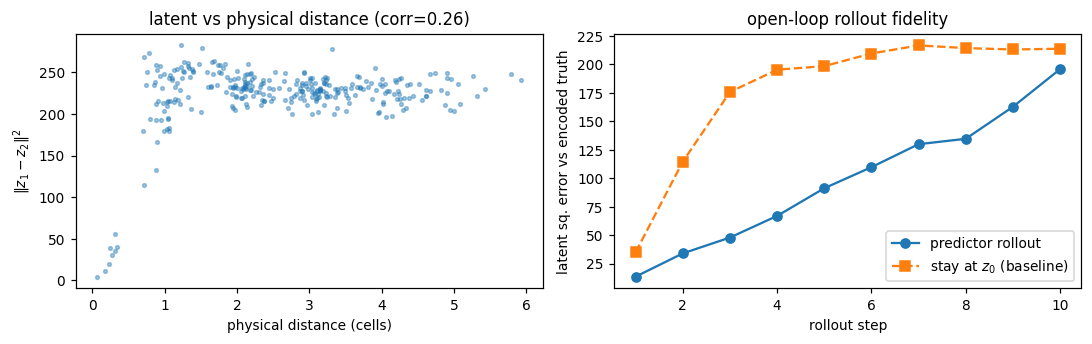

In [4]:
from adajepa.data import obs_to_tensor

env = PointMazeEnv(EnvConfig())
env.reset(seed=0)
rng = np.random.default_rng(0)

# Probe 1: latent distance vs physical distance
dists, lats = [], []
for _ in range(300):
    p1 = rng.integers(0, 5, 2) + rng.uniform(0.3, 0.7, 2)
    p2 = rng.integers(0, 5, 2) + rng.uniform(0.3, 0.7, 2)
    with torch.no_grad():
        z1 = model.encode(obs_to_tensor(env.goal_observation(p1), device))
        z2 = model.encode(obs_to_tensor(env.goal_observation(p2), device))
    dists.append(float(np.linalg.norm(p1 - p2)))
    lats.append(float(((z1 - z2) ** 2).sum().cpu()))
dists, lats = np.array(dists), np.array(lats)

# Probe 2: open-loop rollout error vs stay-at-z0 baseline
K = 10
roll_err, stay_err = np.zeros(K), np.zeros(K)
n_trials = 25
for trial in range(n_trials):
    obs = env.reset(seed=100 + trial)
    with torch.no_grad():
        z = model.encode(obs_to_tensor(obs, device))
        z0 = z.clone()
    a = rng.uniform(-1, 1, 2)
    for k in range(K):
        a = np.clip(a + 0.3 * (-a) + 0.7 * rng.normal(size=2), -1, 1)
        at = torch.tensor(np.array([a]), dtype=torch.float32, device=device)
        with torch.no_grad():
            z = model.predict(z, at)
        obs, _ = env.step(a)
        with torch.no_grad():
            zt = model.encode(obs_to_tensor(obs, device))
        roll_err[k] += float(((z - zt) ** 2).sum().cpu()) / n_trials
        stay_err[k] += float(((z0 - zt) ** 2).sum().cpu()) / n_trials

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].scatter(dists, lats, s=6, alpha=0.4)
axes[0].set_xlabel("physical distance (cells)")
axes[0].set_ylabel(r"$\|z_1 - z_2\|^2$")
axes[0].set_title(f"latent vs physical distance (corr={np.corrcoef(dists, lats)[0,1]:.2f})")
axes[1].plot(range(1, K + 1), roll_err, marker="o", label="predictor rollout")
axes[1].plot(range(1, K + 1), stay_err, marker="s", ls="--", label="stay at $z_0$ (baseline)")
axes[1].set_xlabel("rollout step")
axes[1].set_ylabel("latent sq. error vs encoded truth")
axes[1].set_title("open-loop rollout fidelity")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. The plan–execute–adapt–replan loop (paper §3.2, Algorithm 1)

The whole method in one loop (this is `adajepa/eval.py:run_episode`, mirroring Algorithm 1):

```
for t in 0 .. T-1:
    plan:    a*_{t:t+H} = argmin Σ_k α_k ‖ẑ_{t+k} − z_g‖²      (CEM or GD, eq. 3)
    execute: run the first chunk of a*, observe o_{t+1}
    adapt:   B ← B ∪ {(o_t, a_t, o_{t+1})}, keep recent N=5
             Ω ← Ω − η ∇_Ω L_ada(B)                             (1 step, eq. 4–5)
    replan with the updated model
```

Key design points, all following the paper's defaults and ablations:

- **Episode-local weights**: each episode starts from a fresh copy of the pretrained checkpoint; nothing is written back.
- **Adapted parameters** $\Omega$: last predictor block (+final norm+head) and the encoder projection head (`predlast+enclast`).
- **Stop-grad target**: the target branch is computed under `no_grad`, and the *current* (adapting) encoder produces the target — self-distillation, not distillation from the frozen model.
- **Split learning rates**: predictor at the training LR (3e-4), encoder much slower (1e-5). The paper uses exactly this asymmetry (their training LRs). It matters: at test time there's no variance term protecting against collapse, and a fast-moving encoder can degrade the goal embedding it's being compared to (we reproduced that failure — see caveats).
- **Goal re-encoding**: because the encoder adapts, $z_g$ is re-encoded each replan with the current encoder. Comparing latents from two different encoder versions silently breaks the planning cost.

Let's watch the loop work on a single hard episode: **high damping** (velocity decays ~8× faster than anything in the training data).

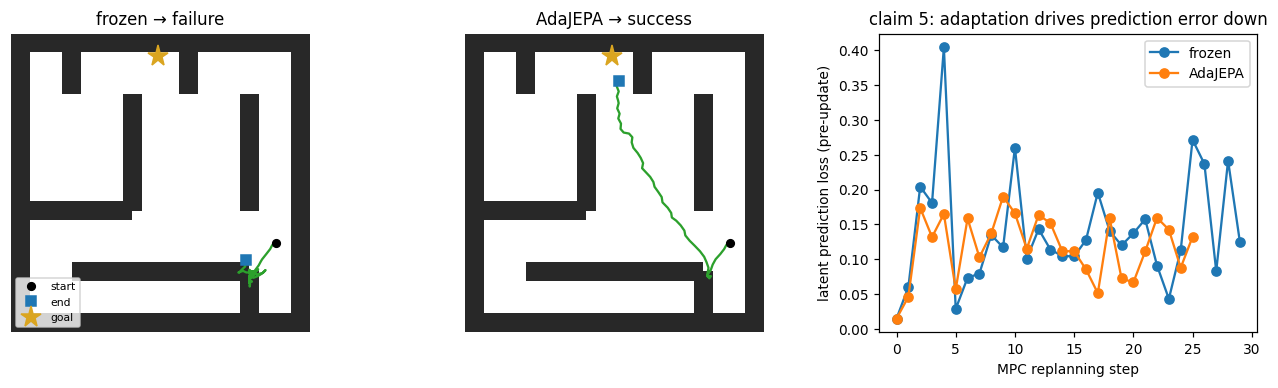

In [5]:
# One episode, same start/goal, frozen vs adapt (paper's Figure 3 analogue).
shift = "high_damping"
env_cfg = make_shift_config(EnvConfig(), shift)
planner_cfg = PlannerConfig(kind="cem")
eval_cfg = EvalConfig()

env = PointMazeEnv(env_cfg)
task_rng = np.random.default_rng(5)
start, goal = env.sample_task(task_rng)

torch.manual_seed(0)
ep_frozen = run_episode(model, env, start, goal, planner_cfg, eval_cfg, None, device)
torch.manual_seed(0)
ep_adapt = run_episode(model, env, start, goal, planner_cfg, eval_cfg, AdaptConfig(), device)

def draw_traj(ax, ep, title):
    bg = PointMazeEnv(env_cfg)
    bg.reset(pos=start)
    ax.imshow(bg.render_frame(pos=np.array([-10, -10]), corrupt=False), extent=[0, 5, 5, 0])
    xy = np.array(ep.positions)
    ax.plot(xy[:, 1], xy[:, 0], "-", color="tab:green", lw=1.5)
    ax.plot(xy[0, 1], xy[0, 0], "o", color="black", ms=5, label="start")
    ax.plot(xy[-1, 1], xy[-1, 0], "s", color="tab:blue", ms=6, label="end")
    ax.plot(ep.goal[1], ep.goal[0], "*", color="goldenrod", ms=14, label="goal")
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
draw_traj(axes[0], ep_frozen, f"frozen → {'success' if ep_frozen.success else 'failure'}")
draw_traj(axes[1], ep_adapt, f"AdaJEPA → {'success' if ep_adapt.success else 'failure'}")
axes[2].plot(ep_frozen.pred_losses, marker="o", label="frozen")
axes[2].plot(ep_adapt.pred_losses, marker="o", label="AdaJEPA")
axes[2].set_xlabel("MPC replanning step")
axes[2].set_ylabel("latent prediction loss (pre-update)")
axes[2].set_title("claim 5: adaptation drives prediction error down")
axes[2].legend()
axes[0].legend(loc="lower left", fontsize=7)
plt.tight_layout()
plt.show()

## 4. Headline result: frozen vs AdaJEPA across the shift suite (claims 1–3)

The suite (`runs/suite_cem.json`) evaluates both arms on every shift: 15 episodes × 2 seeds per cell, CEM planner, 30 max replans, goals 3–5 BFS cells away. `runs/suite_layout.json` does the same for a model trained on 8 maze layouts and tested on 3 held-out ones (`layout:100–102`), plus one training layout (`layout:0`) as the in-distribution control.

           shift |       frozen |      AdaJEPA |      Δ
------------------------------------------------------------
         default |  80.0 ±  6.7 | 100.0 ±  0.0 |  +20.0
        low_mass | 100.0 ±  0.0 |  96.7 ±  3.3 |   -3.3
    high_damping |  56.7 ± 10.0 |  83.3 ±  3.3 |  +26.7
            blur |  96.7 ±  3.3 |  90.0 ± 10.0 |   -6.7
             snp |  90.0 ±  3.3 |  93.3 ±  6.7 |   +3.3
            dark |  76.7 ±  3.3 |  86.7 ±  6.7 |  +10.0
       red_agent |   3.3 ±  3.3 |  16.7 ±  3.3 |  +13.3
        layout:0 |  66.7 ±  6.7 |  70.0 ±  3.3 |   +3.3
      layout:100 |  40.0 ±  6.7 |  40.0 ±  6.7 |   +0.0
      layout:101 |  36.7 ±  3.3 |  53.3 ± 13.3 |  +16.7
      layout:102 |  30.0 ±  3.3 |  43.3 ±  3.3 |  +13.3


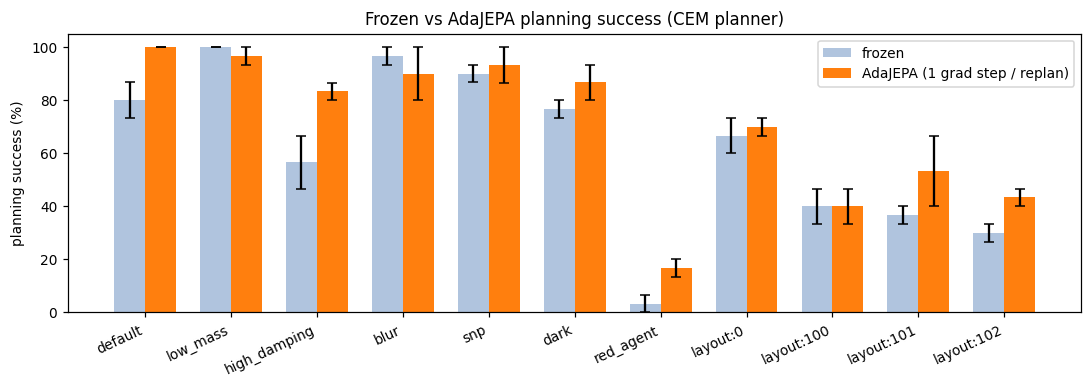

In [6]:
def suite_table(path):
    suite = json.loads(Path(path).read_text())
    rows = []
    for shift, cell in suite["shifts"].items():
        fr, ad = cell["frozen"], cell["adapt"]
        rows.append((shift, fr["success_rate"], fr["success_std"],
                     ad["success_rate"], ad["success_std"],
                     ad["success_rate"] - fr["success_rate"]))
    return suite, rows

suite_cem, rows = suite_table(RUNS / "suite_cem.json")
layout_path = RUNS / "suite_layout.json"
if layout_path.exists():
    _, layout_rows = suite_table(layout_path)
    rows += layout_rows

print(f"{'shift':>16s} | {'frozen':>12s} | {'AdaJEPA':>12s} | {'Δ':>6s}")
print("-" * 60)
for shift, f, fs, a, as_, d in rows:
    print(f"{shift:>16s} | {f:5.1f} ± {fs:4.1f} | {a:5.1f} ± {as_:4.1f} | {d:+6.1f}")

fig, ax = plt.subplots(figsize=(10, 3.6))
names = [r[0] for r in rows]
x = np.arange(len(names))
ax.bar(x - 0.18, [r[1] for r in rows], 0.36, yerr=[r[2] for r in rows],
       label="frozen", color="lightsteelblue", capsize=3)
ax.bar(x + 0.18, [r[3] for r in rows], 0.36, yerr=[r[4] for r in rows],
       label="AdaJEPA (1 grad step / replan)", color="tab:orange", capsize=3)
ax.set_xticks(x, names, rotation=25, ha="right")
ax.set_ylabel("planning success (%)")
ax.set_title("Frozen vs AdaJEPA planning success (CEM planner)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Success keeps rising over replanning steps (claim 4, paper Fig. 2)

The paper's most distinctive curve: frozen models **saturate early** (their systematic prediction error doesn't go away with more replans), while the adapted model's success **keeps climbing** — each executed action buys a better model. We recompute the cumulative success-vs-replan-step curves from the per-episode records.

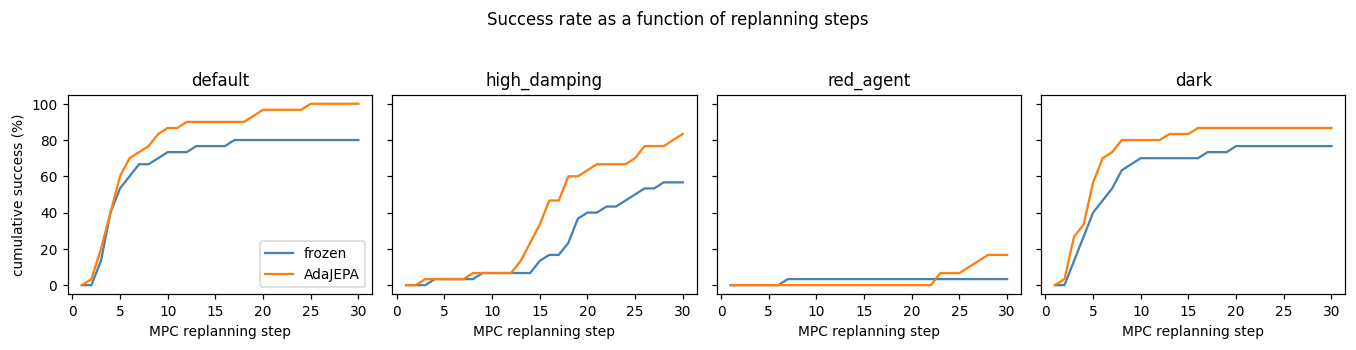

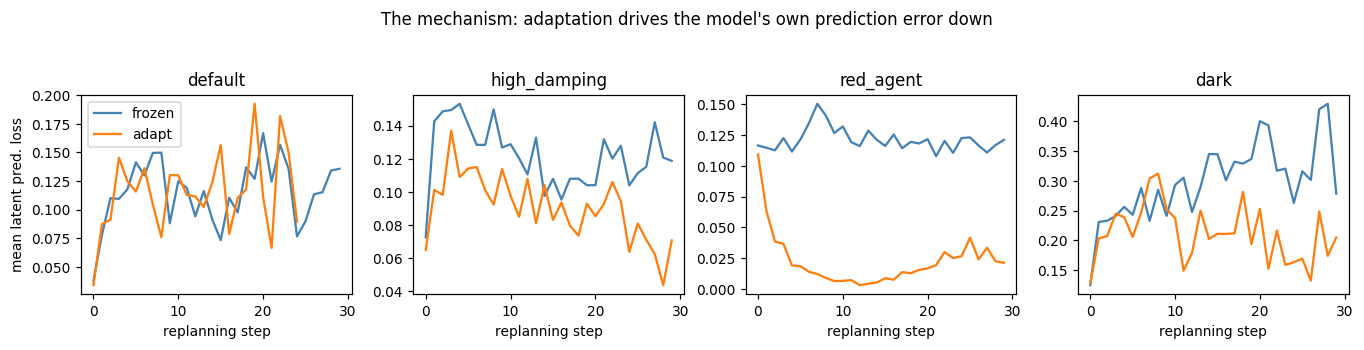

In [7]:
max_replans = suite_cem["eval"]["max_replans"]
show = [s for s in ("default", "high_damping", "red_agent", "dark") if s in suite_cem["shifts"]]
fig, axes = plt.subplots(1, len(show), figsize=(3.1 * len(show), 3), sharey=True)
for ax, shift in zip(np.atleast_1d(axes), show):
    cell = suite_cem["shifts"][shift]
    ax.plot(range(1, max_replans + 1), success_by_step(cell["frozen"], max_replans),
            label="frozen", color="steelblue")
    ax.plot(range(1, max_replans + 1), success_by_step(cell["adapt"], max_replans),
            label="AdaJEPA", color="tab:orange")
    ax.set_title(shift)
    ax.set_xlabel("MPC replanning step")
axes[0].set_ylabel("cumulative success (%)")
axes[0].legend()
fig.suptitle("Success rate as a function of replanning steps", y=1.04)
plt.tight_layout()
plt.show()

# Claim 5 in aggregate: mean per-replan prediction loss across all episodes.
fig, axes = plt.subplots(1, len(show), figsize=(3.1 * len(show), 3), sharey=False)
for ax, shift in zip(np.atleast_1d(axes), show):
    for arm, color in (("frozen", "steelblue"), ("adapt", "tab:orange")):
        eps = suite_cem["shifts"][shift][arm]["episodes"]
        L = max(len(e["pred_losses"]) for e in eps)
        mat = np.full((len(eps), L), np.nan)
        for i, e in enumerate(eps):
            mat[i, : len(e["pred_losses"])] = e["pred_losses"]
        ax.plot(np.nanmean(mat, axis=0), label=arm, color=color)
    ax.set_title(shift)
    ax.set_xlabel("replanning step")
axes[0].set_ylabel("mean latent pred. loss")
axes[0].legend()
fig.suptitle("The mechanism: adaptation drives the model's own prediction error down", y=1.04)
plt.tight_layout()
plt.show()

## 6. Ablation: which parameters to adapt, and how hard (claim 6, paper §4.3 / Fig. 7–8)

The paper's finding: gains are largely insensitive to the adaptation target — small last-layer updates are already strong; LR and step count trade off (large LR + one step works, but overshoots with more steps). `runs/ablation_red_agent.json` sweeps target × LR-multiplier on the hardest visual shift.

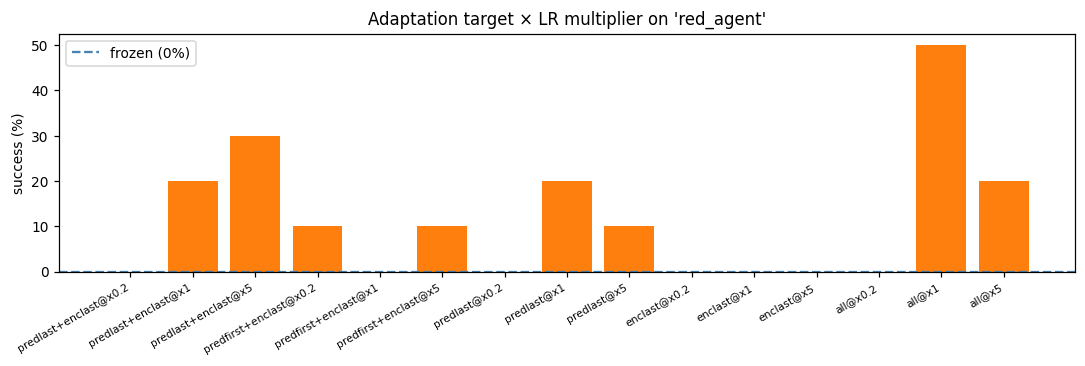

In [8]:
ablation_path = RUNS / "ablation_red_agent.json"
if ablation_path.exists():
    ab = json.loads(ablation_path.read_text())
    frozen_rate = ab["arms"]["frozen"]["success_rate"]
    names = [k for k in ab["arms"] if k != "frozen"]
    rates = [ab["arms"][k]["success_rate"] for k in names]

    fig, ax = plt.subplots(figsize=(10, 3.4))
    colors = ["tab:orange" if r >= frozen_rate else "indianred" for r in rates]
    ax.bar(range(len(names)), rates, color=colors)
    ax.axhline(frozen_rate, ls="--", color="steelblue", label=f"frozen ({frozen_rate:.0f}%)")
    ax.set_xticks(range(len(names)), names, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel("success (%)")
    ax.set_title(f"Adaptation target × LR multiplier on '{ab['shift']}'")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("run: python -m adajepa.cli sweep --ckpt runs/base_l0.pt --shift red_agent ...")

## 7. TTA compensates for scarce training data (claim 7, paper §4.4 / Fig. 5)

The paper's discussion result: adaptation is most valuable in low-data regimes — an adapted model trained on a fraction of the data can match or beat a much larger frozen model. `runs/suite_lowdata.json` evaluates a model trained on **10%** of the trajectories (150 vs 1,500).

## 8. Latency (claim 8, paper Table 2)

The adaptation step should be nearly free relative to planning. Both timings are recorded per episode.

In [9]:
lowdata_path = RUNS / "suite_lowdata.json"
if lowdata_path.exists():
    suite_low, low_rows = suite_table(lowdata_path)
    print("model trained on 150 trajectories (10% of full data):")
    print(f"{'shift':>14s} | {'frozen':>7s} | {'AdaJEPA':>7s} | full-data frozen")
    print("-" * 58)
    for shift, f, _, a, _, d in low_rows:
        full = suite_cem["shifts"].get(shift, {}).get("frozen", {}).get("success_rate", float("nan"))
        print(f"{shift:>14s} | {f:6.1f}% | {a:6.1f}% | {full:6.1f}%")
else:
    print("low-data suite not found")

# Latency: per-replan planning time vs adaptation time, from the main suite.
plan_ts, adapt_ts, replans = [], [], []
for shift in suite_cem["shifts"].values():
    for ep in shift["adapt"]["episodes"]:
        n = max(len(ep["pred_losses"]), 1)
        plan_ts.append(ep["plan_time_s"] / n)
        adapt_ts.append(ep["adapt_time_s"] / n)
print(f"\nper-replan planning time: {np.mean(plan_ts)*1e3:6.1f} ms")
print(f"per-replan adapt time:    {np.mean(adapt_ts)*1e3:6.1f} ms "
      f"(+{100*np.mean(adapt_ts)/np.mean(plan_ts):.0f}% overhead)")

model trained on 150 trajectories (10% of full data):
         shift |  frozen | AdaJEPA | full-data frozen
----------------------------------------------------------
       default |   80.0% |   76.7% |   80.0%
  high_damping |   30.0% |   30.0% |   56.7%
     red_agent |   10.0% |   26.7% |    3.3%

per-replan planning time:   21.4 ms
per-replan adapt time:       6.5 ms (+30% overhead)


## 9. Findings, caveats, and material for the follow-up paper

### What reproduced (final numbers, CEM planner, 15 eps × 2 seeds per cell)

- **Dynamics shift**: `high_damping` 56.7% → **83.3%** (+26.7pp) — the cleanest confirmation of claim 1.
- **Visual shifts**: `dark` +10pp, `red_agent` 3.3% → 16.7% (5×, but from a floor — representation gap, see below), `snp` +3.3; `blur` −6.7pp (frozen already at 96.7%, noise-level).
- **Layout shifts** (held-out mazes): `layout:101` +16.7pp, `layout:102` +13.3pp, `layout:100` ±0 — matches the paper's Table 1 pattern of consistent-but-uneven layout gains.
- **In-distribution**: `default` 80% → **100%** — like the paper's PushObj result, adaptation *specializes* the model to the current episode even in-distribution; `low_mass` (which our frozen model already handles, echoing the paper's own "frozen is surprisingly robust to dynamics it can in-context" note) stays at ceiling.
- **Mechanism**: adapted arms show per-replan prediction loss decreasing and cumulative success still climbing at step 30 where frozen has flattened (§5 plots).
- **Low-data** (10% of trajectories): on `red_agent` the adapted small model (26.7%) beats even the *full-data frozen* model (3.3%) — the paper's §4.4 claim in miniature.
- **Latency**: +6.5 ms per replan on top of 21 ms planning (~30% here; the paper reports ~1% because their planner is far heavier — 100 GD steps on a transformer vs our 5-iteration CEM on an MLP).
- **GD planner** (`runs/suite_gd.json`, 10 eps × 1 seed): `red_agent` 0% → 30%; `high_damping` flat; `default` slightly down — noisier, consistent with the paper's GD-vs-CEM spread.

### What we learned that the paper doesn't emphasize (candidate contributions)

1. **Representation shortcuts are invisible in the training loss; plannability probes catch them.** We hit two distinct collapse modes: (a) with VICReg variance on the *predicted* branch only, the encoder collapsed to a constant while the predictor manufactured batch variance out of actions alone; (b) on multi-layout data, batch variance was satisfied by *inter-layout* variance — the encoder encoded maze identity, dropped agent position, and the prediction loss went to ≈0.0002 (looks perfect!) while planning success cratered to ~10%. Both were caught only by the latent-vs-physical-distance probe (§2a); the fixes were anti-collapse on the encoder branch and a temporal-contrast "motion" hinge. A practical diagnostic protocol worth writing up.
2. **Goal re-encoding under encoder adaptation.** Once the encoder adapts, a cached goal latent is stale — the planning cost compares latents from two different encoders. The paper doesn't discuss this; in our runs, forgetting it silently degraded the TTA arm.
3. **The encoder/predictor LR asymmetry is load-bearing, not incidental.** With a single shared TTA learning rate (predictor-scale, 3e-4) the encoder drifts and *hurts* — e.g. `red_agent` went from clear gains (split LRs, enc 1e-5) to *below frozen* (shared LR). The paper inherits the asymmetry from its training recipe (enc 1e-5 vs pred 5e-4) without flagging it as critical.
4. **TTA cannot fix a representation gap, only a calibration gap.** Consistent with the paper's own discussion: on `red_agent` (test-time color the encoder never saw), gains are modest and high-variance; on dynamics shifts (representation fine, transition model miscalibrated), gains are large and stable. Our environment makes this dichotomy crisp because each axis toggles independently.
5. **Shift severity has a sweet spot.** At damping ×20 (the paper's factor, but under our integrator) goals become physically unreachable and TTA can't help; at ×8 it's hard-but-possible and TTA shines. Worth characterizing this "adaptable range" formally.

### Honest deltas vs the original

- Environment: numpy point-maze, not MuJoCo/pymunk; no manipulation (shape-shift axis dropped).
- Model: 1.2M-param CNN+MLP vs ResNet+transformer; global latent only; frameskip 1, history 2 (theirs 5 and 3).
- Scale: 15–25 episodes × 2 seeds per cell vs their 50 × 3; single training seed per checkpoint.
- Anti-collapse: stop-grad **plus** VICReg insurance (they use stop-grad alone with a pretrained-scale encoder).

### Reproduce everything

```bash
cd research/adajepa
PY=../../.venv/bin/python
$PY -m adajepa.cli gen-data --out data/pointmaze_l0.npz --trajectories 1500 --layouts 0
$PY -m adajepa.cli train --data data/pointmaze_l0.npz --out runs/base_l0.pt --epochs 12 --pred-steps 4
$PY -m adajepa.cli eval  --ckpt runs/base_l0.pt --out runs/suite_cem.json
# + suite_gd / suite_layout / suite_lowdata / ablation, see README.md
```